In [29]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

импорт датасета и подготовка данных

In [30]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/funcan-cases/world_country.csv'
df = pd.read_csv(file_path)

def haversine(lat1, lon1, lat2, lon2):
  """
  считаем метрики на шаре (потому что земля оказывается не плоская :( )
  """
  # переводим в радианы
  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
  c = 2 * np.arcsin(np.sqrt(a))
  r = 6371 # радиус Земли в километрах
  return c * r

df = df.dropna(subset=['lat', 'lon'])

N = len(df)
D = np.zeros((N, N))

lats = df['lat'].values
lons = df['lon'].values

for i in range(N):
    for j in range(i + 1, N):
        dist = haversine(lats[i], lons[i], lats[j], lons[j])
        D[i, j] = dist
        D[j, i] = dist

# проверка диагонали
flag = True
for i in range(N):
  if D[i][i] != 0:
    flag = False
if flag:
  print("диагональ матрицы нулевая")

# проверка симметрии
if np.allclose(D, D.T):
  print("матрица расстояний симметрична")

# проверка неравенства треугольника
flag = True
count_err = 0
for i in range(N):
  for j in range (N):
    for k in range (N):
      if D[i][j] > D[i][k] + D[k][j]:
        flag = False
        count_err += 1
if flag:
  print("неравенство треугольника выполняется для всех троек расстояний матрицы")
else:
  print(f'неравенство треугольника не выполняется для {count_err} троек матрицы из-за кривизны Земли или погрешностей округления')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
диагональ матрицы нулевая
матрица расстояний симметрична
неравенство треугольника выполняется для всех троек расстояний матрицы


построение матрицы квадратов расстояний, матрицы центрировоания и матрицы Грама

In [42]:
import numpy as np

# нормализация на среднее значение
D_mean = np.mean(D)
D_norm = D / D_mean

D_sq = D_norm**2
N = len(D_norm)
J = np.eye(N) - (1/N) * np.ones((N, N))

# матрица Грама для нормализованных данных
B = -0.5 * J @ D_sq @ J

print(f'среднее расстояние D: {D_mean:.2f} км')
print(f'матрица Грама (фрагмент после нормализации):\n{B[:3, :3]}')

среднее расстояние D: 8473.13 км
матрица Грама (фрагмент после нормализации):
[[0.38394513 0.17786664 0.07350499]
 [0.17786664 0.20760641 0.20278393]
 [0.07350499 0.20278393 0.26043863]]


In [43]:
mean_dist = np.mean(D)
print(f"среднее значение в матрице расстояний D: {mean_dist:.2f} км")

mean_dist_no_diag = D.sum() / (N * (N - 1))
print(f"среднее расстояние между различными точками: {mean_dist_no_diag:.2f} км")

среднее значение в матрице расстояний D: 8473.13 км
среднее расстояние между различными точками: 8508.28 км


проверка симметричности матрицы Грама, нахождение её собственных значений и их анализ, определение её ранга

матрица Грама симметрична
собственные значения матрицы Грама: [ 8.70825283e+01  7.41369157e+01  3.11730973e+01  5.41281934e+00
  3.95553947e+00  3.54046842e+00  2.28268978e+00  1.69194227e+00
  1.60921950e+00  1.13697364e+00  9.69173191e-01  8.54526554e-01
  6.52299571e-01  5.59857749e-01  4.58075270e-01  4.42568142e-01
  3.69138215e-01  3.41350485e-01  3.22216478e-01  2.94375006e-01
  2.23256055e-01  2.18825984e-01  1.75602194e-01  1.57192801e-01
  1.45026428e-01  1.32764543e-01  1.23966444e-01  1.10466832e-01
  8.59573259e-02  7.37888560e-02  7.05780787e-02  6.73062823e-02
  5.62577294e-02  4.78763905e-02  4.30713744e-02  3.76913860e-02
  3.13413840e-02  2.93687184e-02  2.61040856e-02  1.81563967e-02
  1.72434440e-02  1.49319415e-02  1.15201172e-02  6.10958295e-03
  3.91009435e-03  3.11387172e-03  2.25729412e-03  1.42970421e-03
  7.72328320e-04  3.97059811e-04  2.07473999e-04  1.75279802e-04
  1.05037556e-04  5.11410752e-05  3.19471772e-05  2.18158383e-05
  1.27365442e-05  1.12948178

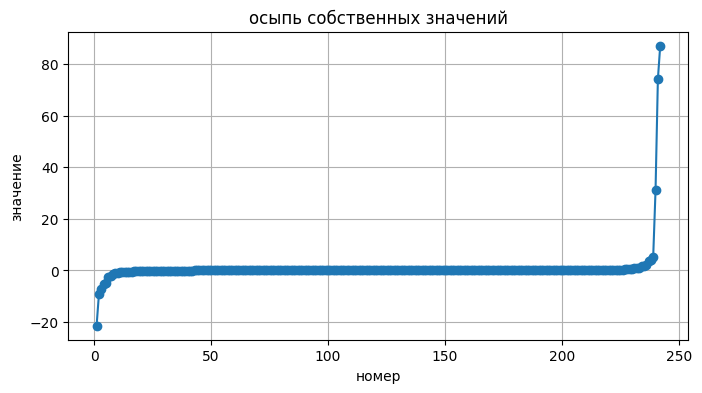

In [44]:
if np.allclose(B, B.T):
  print("матрица Грама симметрична")
else:
  print("матрицв Грама не симметрична")

eig_values, eig_vectors = np.linalg.eigh(B)
print(f'собственные значения матрицы Грама: {np.sort(eig_values)[::-1]}')

positive_count = np.sum(eig_values > 0)
zero_count = np.sum(eig_values == 0)
negative_count = np.sum(eig_values < 0)
print(f'число положительных собственных значений: {positive_count}')
print(f'число нулевых собственных значений: {zero_count}')
print(f'число отрицательных собственных значений: {negative_count}')

rank = np.linalg.matrix_rank(B)
print(f'ранг матрицы Грама: {rank}')

# график собственных значений
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eig_values) + 1), eig_values, marker='o')
plt.title("осыпь собственных значений")
plt.xlabel("номер")
plt.ylabel("значение")
plt.grid(True)
plt.show()

восстановление координат

In [45]:
m = 2

idx = np.argsort(np.abs(eig_values))[::-1]
eig_values_sorted = eig_values[idx]
eig_vectors_sorted = eig_vectors[:, idx]

# используем модуль, чтобы извлечь корень, но сохраняем информацию о структуре
Lambda_m = np.diag(np.sqrt(np.abs(eig_values_sorted[:m])))
U_m = eig_vectors_sorted[:, :m]
Y = U_m @ Lambda_m

print(f"используемые собственные числа (наибольшие по модулю):\n{eig_values_sorted[:m]}")

используемые собственные числа (наибольшие по модулю):
[87.08252829 74.1369157 ]


оценка ощибок и шум

ошибка восстановления (норма Фробениуса): 447912.3326


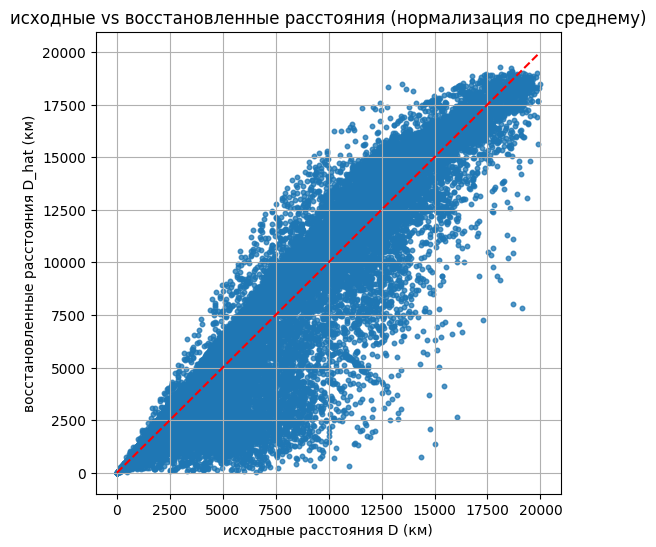

In [46]:
from scipy.spatial.distance import cdist

# восстанавливаем расстояния в нормализованном пространстве
D_hat_norm = cdist(Y, Y, metric='euclidean')

# цумножаем обратно на среднее значение для возврата к километрам
D_hat = D_hat_norm * D_mean

# расчет ошибки (норма Фробениуса)
error_frob = np.linalg.norm(D - D_hat, ord='fro')
print(f"ошибка восстановления (норма Фробениуса): {error_frob:.4f}")

# диаграмма рассеяния
plt.figure(figsize=(6, 6))
plt.scatter(D.flatten(), D_hat.flatten(), alpha=0.5, s=10)
plt.plot([0, D.max()], [0, D.max()], 'r--')
plt.title("исходные vs восстановленные расстояния (нормализация по среднему)")
plt.xlabel("исходные расстояния D (км)")
plt.ylabel("восстановленные расстояния D_hat (км)")
plt.grid(True)
plt.show()

визуализауия

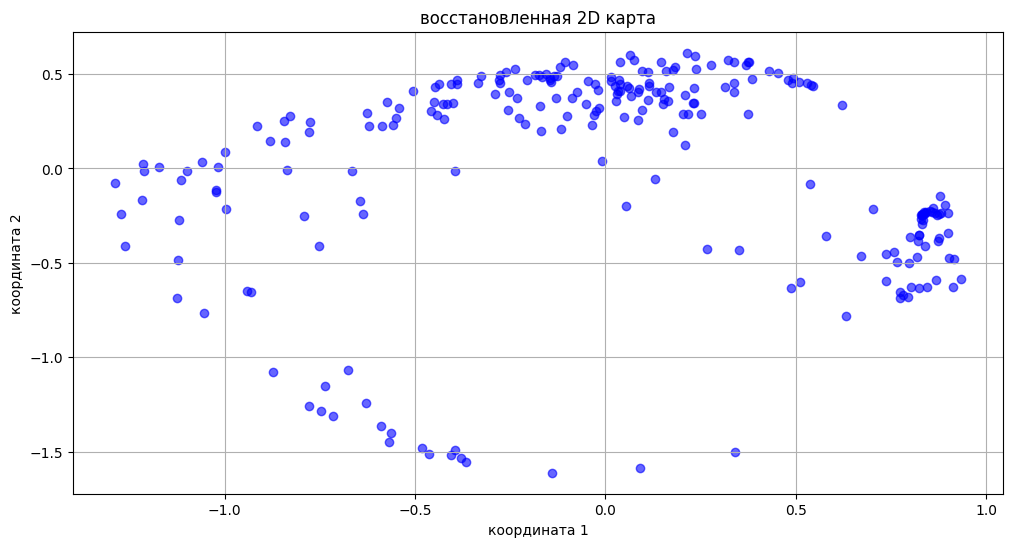

In [48]:
plt.figure(figsize=(12, 6))
plt.scatter(Y[:, 0], Y[:, 1], c='blue', alpha=0.6)

plt.title("восстановленная 2D карта")
plt.xlabel("координата 1")
plt.ylabel("координата 2")
plt.grid(True)
plt.show()